In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
kids_data=pd.read_csv("Hobby_Data.csv")

In [4]:
kids_data.head()

,Olympiad_Participation,Scholarship,School,Fav_sub,Projects,Grasp_pow,Time_sprt,Medals,Career_sprt,Act_sprt,Fant_arts,Won_arts,Time_art,Predicted Hobby
0,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
1,Yes,Yes,Yes,Mathematics,Yes,3,2,No,No,No,No,No,1,Academics
2,Yes,Yes,Yes,Science,Yes,5,1,Yes,No,No,No,No,1,Academics
3,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
4,Yes,Yes,Yes,Science,Yes,5,3,No,No,No,No,No,2,Academics


In [5]:
print("Number of rows:",kids_data.shape[0])
print("Number of columns:",kids_data.shape[1])

Number of rows: 1601
Number of columns: 14


In [6]:
kids_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Olympiad_Participation  1601 non-null   object
 1   Scholarship             1601 non-null   object
 2   School                  1601 non-null   object
 3   Fav_sub                 1601 non-null   object
 4   Projects                1601 non-null   object
 5   Grasp_pow               1601 non-null   int64 
 6   Time_sprt               1601 non-null   int64 
 7   Medals                  1601 non-null   object
 8   Career_sprt             1601 non-null   object
 9   Act_sprt                1601 non-null   object
 10  Fant_arts               1601 non-null   object
 11  Won_arts                1601 non-null   object
 12  Time_art                1601 non-null   int64 
 13  Predicted Hobby         1601 non-null   object
dtypes: int64(3), object(11)
memory usage: 175.2+ KB


In [7]:
kids_data.describe()

,Grasp_pow,Time_sprt,Time_art
count,1601.000000,1601.000000,1601.000000
mean,3.480325,3.033729,2.234229
std,1.006737,1.347725,1.266186
min,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000
50%,3.000000,3.000000,2.000000
75%,4.000000,4.000000,3.000000
max,6.000000,6.000000,6.000000


In [8]:
kids_data.isnull().sum()

Olympiad_Participation    0
Scholarship               0
School                    0
Fav_sub                   0
Projects                  0
Grasp_pow                 0
Time_sprt                 0
Medals                    0
Career_sprt               0
Act_sprt                  0
Fant_arts                 0
Won_arts                  0
Time_art                  0
Predicted Hobby           0
dtype: int64

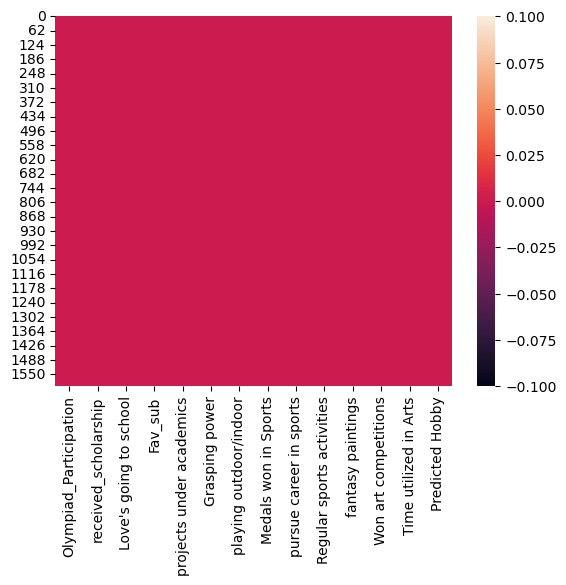

In [12]:
sns.heatmap(kids_data.isnull())
plt.show()

In [9]:
kids_data.rename(columns = {'Scholarship':'received_scholarship','School':'Love\'s going to school','Projects':'projects under academics','Grasp_pow':'Grasping power','Time_sprt':'playing outdoor/indoor','Medals':'Medals won in Sports','Career_sprt':'pursue career in sports','Act_sprt':'Regular sports activities','Fant_arts':'fantasy paintings','Won_arts':'Won art competitions','Time_art':'Time utilized in Arts'}, inplace = True)

In [10]:
kids_data

,Olympiad_Participation,received_scholarship,Love's going to school,Fav_sub,projects under academics,Grasping power,playing outdoor/indoor,Medals won in Sports,pursue career in sports,Regular sports activities,fantasy paintings,Won art competitions,Time utilized in Arts,Predicted Hobby
0,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
1,Yes,Yes,Yes,Mathematics,Yes,3,2,No,No,No,No,No,1,Academics
2,Yes,Yes,Yes,Science,Yes,5,1,Yes,No,No,No,No,1,Academics
3,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
4,Yes,Yes,Yes,Science,Yes,5,3,No,No,No,No,No,2,Academics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,No,No,Yes,Science,No,3,1,Yes,Yes,Yes,No,No,2,Sports
1597,Yes,No,Yes,Any language,Yes,4,3,No,Yes,No,No,Yes,4,Sports
1598,Yes,No,Yes,Any language,No,3,3,No,Yes,No,No,Maybe,2,Sports
1599,Yes,Yes,Yes,Any language,No,4,3,Yes,Yes,No,Yes,Maybe,2,Sports


## Data Analysis

### Which hobbies do kids prefer more?

In [27]:
hobbies=kids_data.groupby("Predicted Hobby").size()
hobbies

Predicted Hobby
Academics    699
Arts         410
Sports       492
dtype: int64

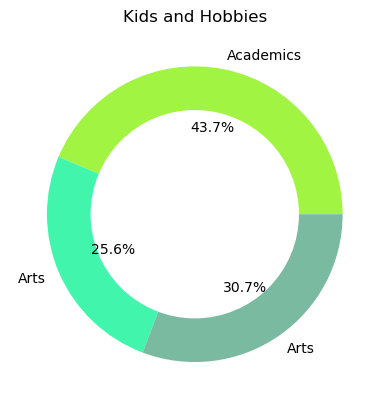

In [28]:
colors = ['#a1f542', '#42f5ad','#7ABAA1']
my_circle = plt.Circle((0, 0), 0.7, color='white')
names=["Academics","Arts","Sports"]

plt.pie(hobbies,labels=names, autopct='%1.1f%%',colors=colors)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Kids and Hobbies")
plt.show()

### Which subjects are most preferred by kids?

In [29]:
subj=kids_data.groupby("Fav_sub").size()
subj

Fav_sub
Any language         288
History/Geography    118
Mathematics          680
Science              515
dtype: int64

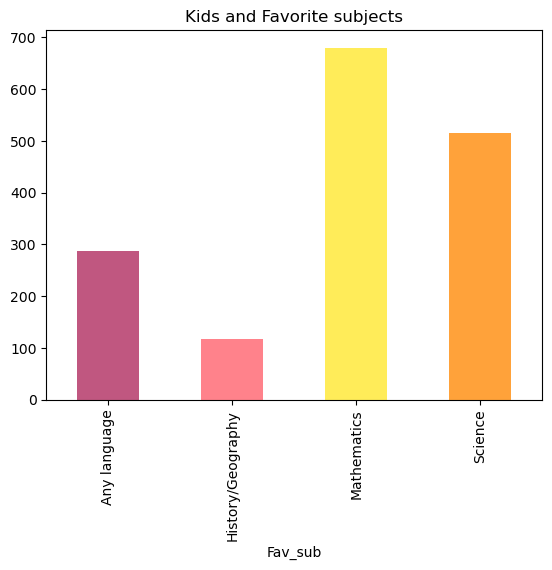

In [30]:
color = ['#C05780', '#FF828B','#FFEC59','#FFA23A']
subj.plot(kind="bar",color=color)
plt.title("Kids and Favorite subjects")
plt.show()

### What is the average amount of time spent for art?

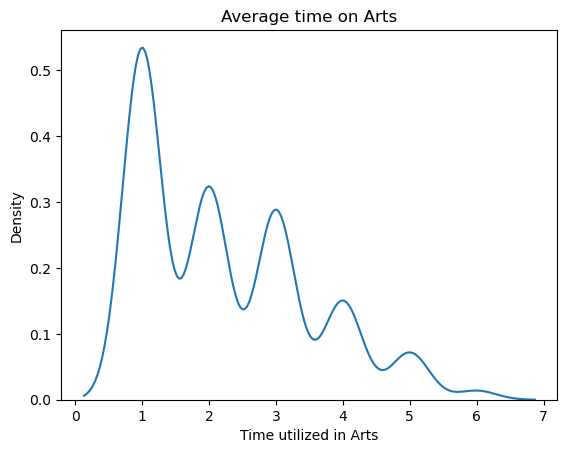

In [31]:
sns.kdeplot(data=kids_data, x="Time utilized in Arts")
plt.title("Average time on Arts")
plt.show()

### What percentage of students has received scholarships?

In [32]:
scholar=kids_data.groupby("received_scholarship").size()
scholar

received_scholarship
No     933
Yes    668
dtype: int64

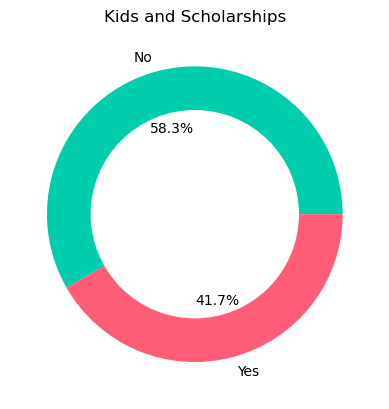

In [40]:
colors = ['#00CDAC', '#FF5C77']
my_circle = plt.Circle((0, 0), 0.7, color='white')
names=["No","Yes"]

plt.pie(scholar,labels=names, autopct='%1.1f%%',colors=colors)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Kids and Scholarships")
plt.show()

### Average amount of time spent playing outdoors/indoors?

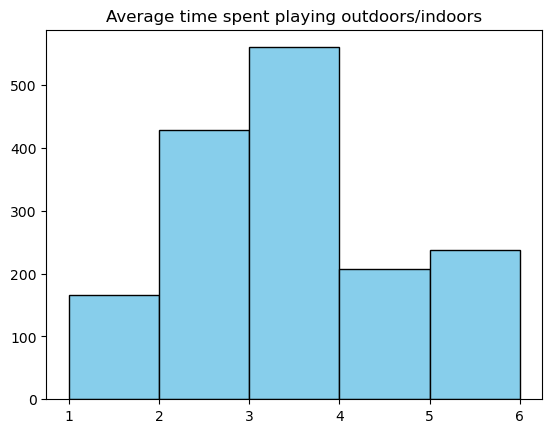

In [67]:
plt.hist(kids_data["playing outdoor/indoor"], bins=5, color='skyblue', edgecolor='black')
plt.title("Average time spent playing outdoors/indoors")
plt.show()

### What percentage of kids has won Art competitions?

In [42]:
compt=kids_data.groupby("Won art competitions").size()
compt

Won art competitions
Maybe    323
No       833
Yes      445
dtype: int64

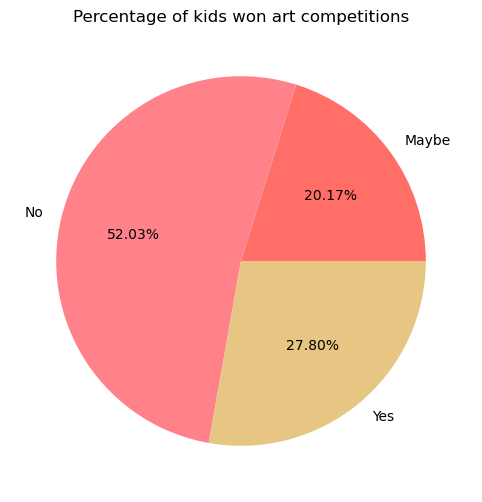

In [48]:
compt.plot(kind='pie',autopct="%.2f%%",figsize=(12,6),colors= ['#FF6F68', '#FF828B','#E7C582'])
plt.title("Percentage of kids won art competitions")
plt.show()

### What is the average grasping power of kids?

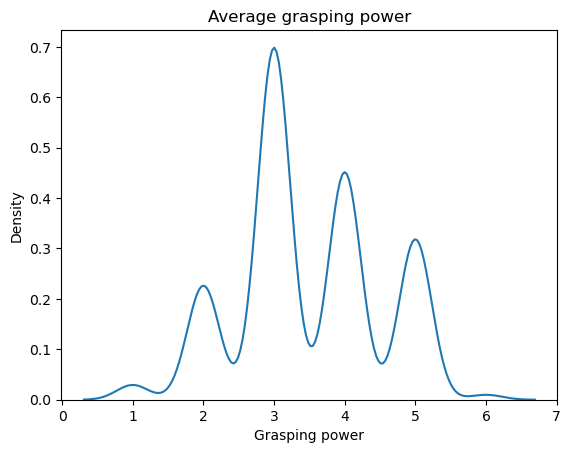

In [65]:
sns.kdeplot(data=kids_data, x="Grasping power")
plt.title("Average grasping power")
plt.show()